In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
sfreq = 32
paradigm = P300(resample=sfreq, tmin=0, tmax=0.7, fmin=0.5, fmax=16)
dataset = BNCI2014009()
subject, session, run = 1, "session_0", "run_0"

#dataset = EPFLP300()
#subject, session, run = 1, "session_1", "run_1"


In [3]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Not setting metadata
576 matching events found
No baseline correction applied


Number of events,576
Events,NonTarget: 480Target: 96
Time range,0.000 – 0.656 sec
Baseline,off


No projector specified for this dataset. Please consider the method self.add_proj.


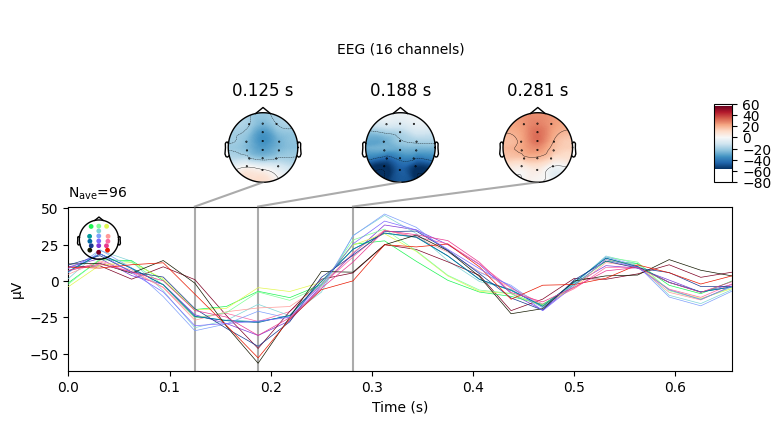

No projector specified for this dataset. Please consider the method self.add_proj.


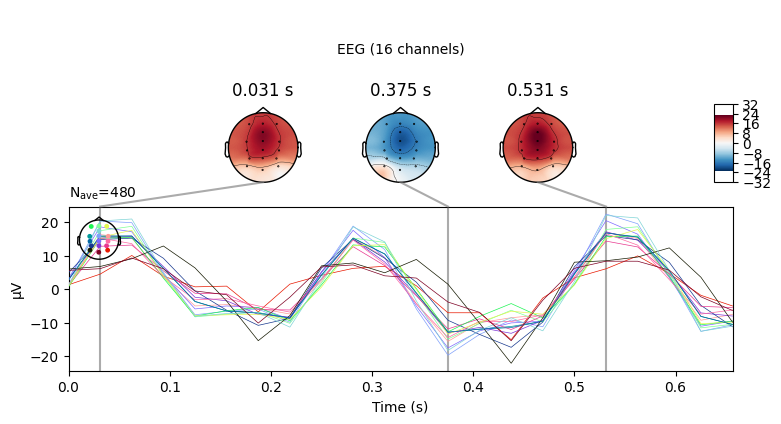

No projector specified for this dataset. Please consider the method self.add_proj.


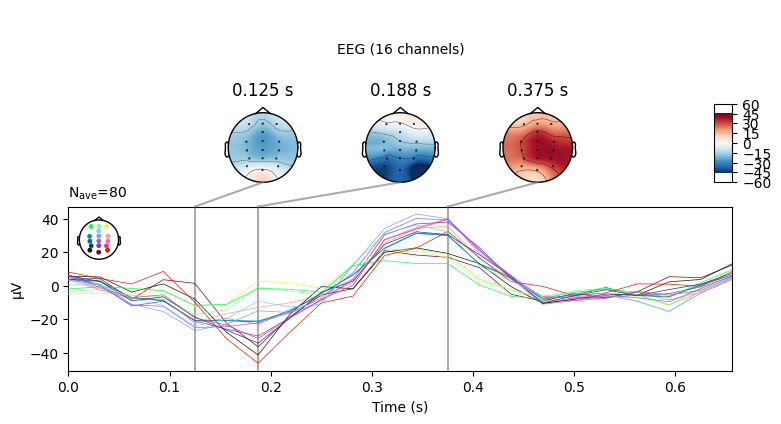

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
_ = target.plot_joint()
non_target = epochs['NonTarget'].average()
_ = non_target.plot_joint()
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint()

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [6]:
tmin = epochs.tmin
sfreq = epochs.info['sfreq']

def lagged_tensor(X, y=None):    
    window = .35
    max_lag = .35
    
    n_epochs, n_channels, _ = X.shape
    roi0 = int((0 - tmin)*sfreq)
    roi1 = int((window - tmin)*sfreq)
    n_times = roi1-roi0
    n_lags= int(max_lag*sfreq)
    Xt = np.zeros((n_epochs, n_channels, n_times, n_lags))
    for l in range(n_lags):
        Xt[:,:,:,l] = X[:,:,roi0+l:roi1+l]
    return Xt

In [7]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from hoda.hoda import MLSVD
from mne.decoding import Scaler

X = epochs.get_data(picks='eeg')
split = len(epochs)//2
X_train = X[:split]
X_test = X[split:]
y_train = labels[:split]
y_test = labels[split:]


scaler = Scaler(scalings='mean', with_mean=False)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train = lagged_tensor(X_train)
X_test = lagged_tensor(X_test)

tl.set_backend('numpy')


#mlsvd = MLSVD(modes=(0,), rank=(16,))
#X_train = mlsvd.fit_transform(X_train)
#X_test = mlsvd.transform(X_test)
#factors = mlsvd.factors_
factors = [np.eye(X_train.shape[1+k]) for k in range(len(X_train.shape[1:]))]

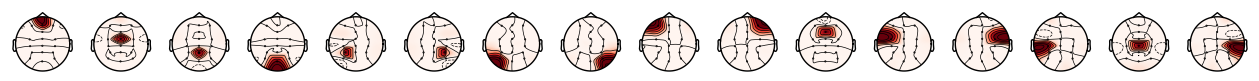

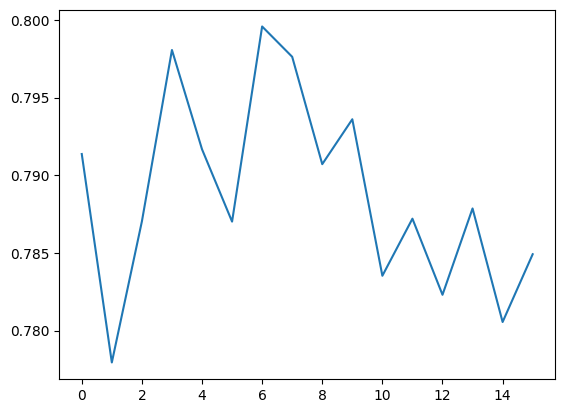

In [8]:
fig, axs = plt.subplots(1, X_train.shape[1], figsize=(16,6))
for i in range(X_train.shape[1]):
    w = factors[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[i], show=False)
plt.show()
plt.plot(np.abs(X_train).mean(axis=(0,2,3)))

In [9]:
hoda = HODA(max_iter=512, rank=5, tol=1e-6,
            initialize ='svd', verbose=True,
            shrinkage=('oas','oas','oas'), toeplitz=(1,2), solver='ratio-gevd')
#%lprun -f hoda.fit hoda.fit(X_train,y_train)
hoda.fit(X_train,y_train)

[0/512]  shrinkage=0.0094  shrinkage=0.0540  shrinkage=0.0540  step=3.3827e+00
[1/512]  shrinkage=0.0094  shrinkage=0.0641  shrinkage=0.0641  step=1.3273e+00
[2/512]  shrinkage=0.0095  shrinkage=0.0690  shrinkage=0.0690  step=1.0367e+00
[3/512]  shrinkage=0.0094  shrinkage=0.0632  shrinkage=0.0632  step=8.6087e-01
[4/512]  shrinkage=0.0095  shrinkage=0.0741  shrinkage=0.0741  step=1.2701e+00
[5/512]  shrinkage=0.0095  shrinkage=0.0690  shrinkage=0.0690  step=1.0583e+00
[6/512]  shrinkage=0.0096  shrinkage=0.0755  shrinkage=0.0755  step=1.0845e+00
[7/512]  shrinkage=0.0095  shrinkage=0.0714  shrinkage=0.0714  step=9.3789e-01
[8/512]  shrinkage=0.0096  shrinkage=0.0761  shrinkage=0.0761  step=9.1875e-01
[9/512]  shrinkage=0.0095  shrinkage=0.0721  shrinkage=0.0721  step=8.1169e-01
[10/512]  shrinkage=0.0096  shrinkage=0.0765  shrinkage=0.0765  step=7.8061e-01
[11/512]  shrinkage=0.0095  shrinkage=0.0725  shrinkage=0.0725  step=7.1611e-01
[12/512]  shrinkage=0.0096  shrinkage=0.0770  shri

[108/512]  shrinkage=0.0096  shrinkage=0.0798  shrinkage=0.0798  step=1.2097e+00
[109/512]  shrinkage=0.0096  shrinkage=0.0817  shrinkage=0.0817  step=1.2107e+00
[110/512]  shrinkage=0.0096  shrinkage=0.0798  shrinkage=0.0798  step=1.2116e+00
[111/512]  shrinkage=0.0096  shrinkage=0.0816  shrinkage=0.0816  step=1.2125e+00
[112/512]  shrinkage=0.0096  shrinkage=0.0799  shrinkage=0.0799  step=1.2134e+00
[113/512]  shrinkage=0.0096  shrinkage=0.0816  shrinkage=0.0816  step=1.2143e+00
[114/512]  shrinkage=0.0096  shrinkage=0.0799  shrinkage=0.0799  step=1.2151e+00
[115/512]  shrinkage=0.0096  shrinkage=0.0816  shrinkage=0.0816  step=1.2159e+00
[116/512]  shrinkage=0.0096  shrinkage=0.0799  shrinkage=0.0799  step=1.2167e+00
[117/512]  shrinkage=0.0096  shrinkage=0.0816  shrinkage=0.0816  step=1.2175e+00
[118/512]  shrinkage=0.0096  shrinkage=0.0799  shrinkage=0.0799  step=1.2182e+00
[119/512]  shrinkage=0.0096  shrinkage=0.0816  shrinkage=0.0816  step=1.2189e+00
[120/512]  shrinkage=0.0096 

[210/512]  shrinkage=0.0096  shrinkage=0.0800  shrinkage=0.0800  step=1.2371e+00
[211/512]  shrinkage=0.0096  shrinkage=0.0815  shrinkage=0.0815  step=1.2372e+00
[212/512]  shrinkage=0.0096  shrinkage=0.0800  shrinkage=0.0800  step=1.2372e+00
[213/512]  shrinkage=0.0096  shrinkage=0.0815  shrinkage=0.0815  step=1.2372e+00
[214/512]  shrinkage=0.0096  shrinkage=0.0800  shrinkage=0.0800  step=1.2372e+00
[215/512]  shrinkage=0.0096  shrinkage=0.0815  shrinkage=0.0815  step=1.2372e+00
[216/512]  shrinkage=0.0096  shrinkage=0.0800  shrinkage=0.0800  step=1.2372e+00
[217/512]  shrinkage=0.0096  shrinkage=0.0815  shrinkage=0.0815  step=1.2373e+00
[218/512]  shrinkage=0.0096  shrinkage=0.0800  shrinkage=0.0800  step=1.2373e+00
[219/512]  shrinkage=0.0096  shrinkage=0.0815  shrinkage=0.0815  step=1.2373e+00
[220/512]  shrinkage=0.0096  shrinkage=0.0800  shrinkage=0.0800  step=1.2373e+00
[221/512]  shrinkage=0.0096  shrinkage=0.0815  shrinkage=0.0815  step=1.2373e+00
[222/512]  shrinkage=0.0096 

[314/512]  shrinkage=0.0096  shrinkage=0.0800  shrinkage=0.0800  step=1.2376e+00
[315/512]  shrinkage=0.0096  shrinkage=0.0815  shrinkage=0.0815  step=1.2376e+00
[316/512]  shrinkage=0.0096  shrinkage=0.0800  shrinkage=0.0800  step=1.2376e+00
[317/512]  shrinkage=0.0096  shrinkage=0.0815  shrinkage=0.0815  step=1.2376e+00
[318/512]  shrinkage=0.0096  shrinkage=0.0800  shrinkage=0.0800  step=1.2376e+00
[319/512]  shrinkage=0.0096  shrinkage=0.0815  shrinkage=0.0815  step=1.2376e+00
[320/512]  shrinkage=0.0096  shrinkage=0.0800  shrinkage=0.0800  step=1.2376e+00
[321/512]  shrinkage=0.0096  shrinkage=0.0815  shrinkage=0.0815  step=1.2376e+00
[322/512]  shrinkage=0.0096  shrinkage=0.0800  shrinkage=0.0800  step=1.2376e+00
[323/512]  shrinkage=0.0096  shrinkage=0.0815  shrinkage=0.0815  step=1.2376e+00
[324/512]  shrinkage=0.0096  shrinkage=0.0800  shrinkage=0.0800  step=1.2376e+00
[325/512]  shrinkage=0.0096  shrinkage=0.0815  shrinkage=0.0815  step=1.2376e+00
[326/512]  shrinkage=0.0096 

[417/512]  shrinkage=0.0096  shrinkage=0.0815  shrinkage=0.0815  step=1.2376e+00
[418/512]  shrinkage=0.0096  shrinkage=0.0800  shrinkage=0.0800  step=1.2376e+00
[419/512]  shrinkage=0.0096  shrinkage=0.0815  shrinkage=0.0815  step=1.2376e+00
[420/512]  shrinkage=0.0096  shrinkage=0.0800  shrinkage=0.0800  step=1.2376e+00
[421/512]  shrinkage=0.0096  shrinkage=0.0815  shrinkage=0.0815  step=1.2376e+00
[422/512]  shrinkage=0.0096  shrinkage=0.0800  shrinkage=0.0800  step=1.2376e+00
[423/512]  shrinkage=0.0096  shrinkage=0.0815  shrinkage=0.0815  step=1.2376e+00
[424/512]  shrinkage=0.0096  shrinkage=0.0800  shrinkage=0.0800  step=1.2376e+00
[425/512]  shrinkage=0.0096  shrinkage=0.0815  shrinkage=0.0815  step=1.2376e+00
[426/512]  shrinkage=0.0096  shrinkage=0.0800  shrinkage=0.0800  step=1.2376e+00
[427/512]  shrinkage=0.0096  shrinkage=0.0815  shrinkage=0.0815  step=1.2376e+00
[428/512]  shrinkage=0.0096  shrinkage=0.0800  shrinkage=0.0800  step=1.2376e+00
[429/512]  shrinkage=0.0096 

HODA(initialize='svd', max_iter=512, rank=5, shrinkage=('oas', 'oas', 'oas'),
     solver='ratio-gevd', toeplitz=(1, 2), tol=1e-06, verbose=True)

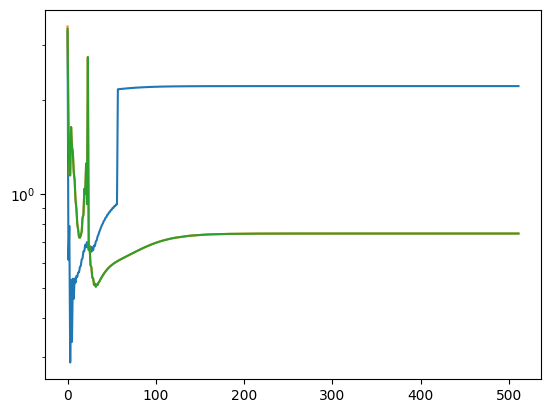

In [10]:
import cupy
plt.semilogy(cupy.asnumpy(hoda.updates_[:,:hoda.iter_]))
plt.show()

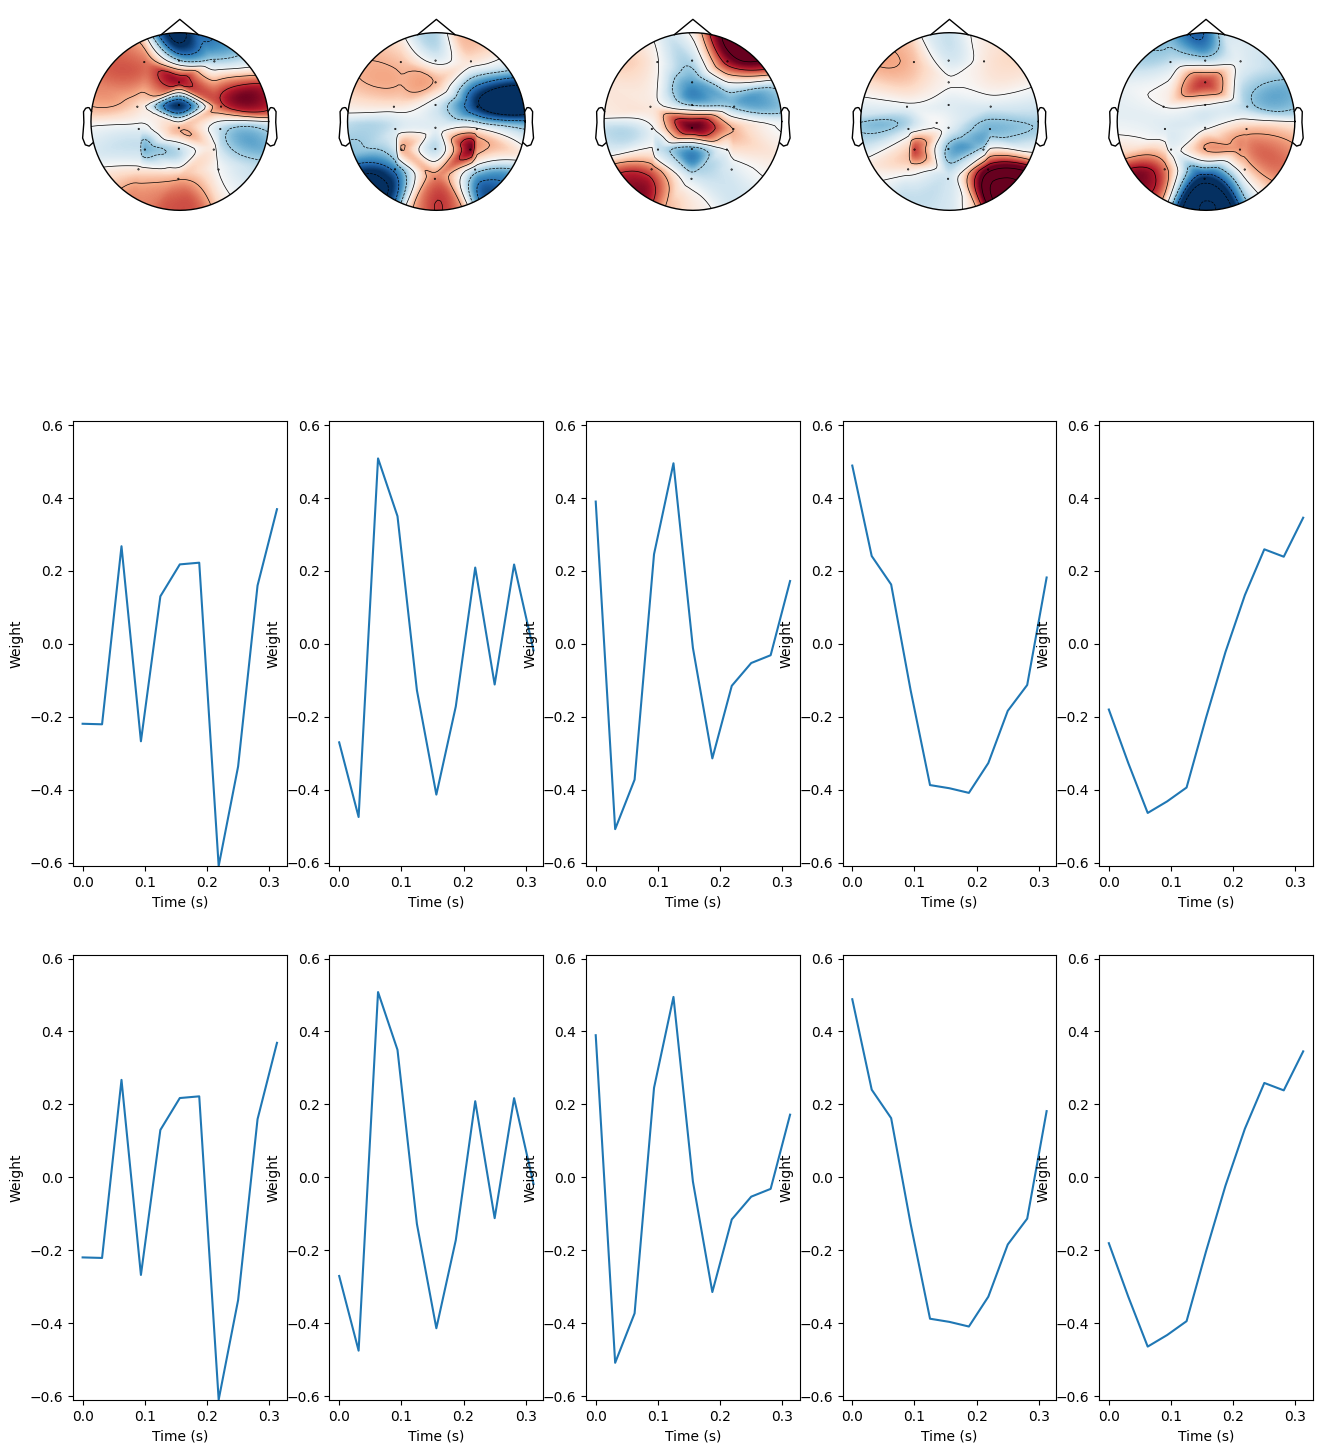

In [11]:

fig, axs = plt.subplots(3,hoda.rank, figsize=(16,6*3))
projs = [cupy.asnumpy(factors[k] @ p) for k,p in enumerate(hoda.projs_)]
for i in range(hoda.rank):
    w = projs[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(projs[1]))
for i in range(hoda.rank):
    w = projs[1][:,i]
    axs[1,i].plot(epochs.times[:len(w)], w)
    axs[1,i].set_xlabel('Time (s)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])
    axs[1,i].sharex(axs[2,0])
    axs[1,i].sharey(axs[2,0])
for i in range(hoda.rank):
    w = cupy.asnumpy(projs[2][:,i])
    axs[2,i].plot(epochs.times[:len(w)], w)
    axs[2,i].set_xlabel('Time (s)')
    axs[2,i].set_ylabel('Weight')
    axs[2,i].set_ylim([-vmax, vmax])
    axs[2,i].sharex(axs[2,0])
    axs[2,i].sharey(axs[2,0])


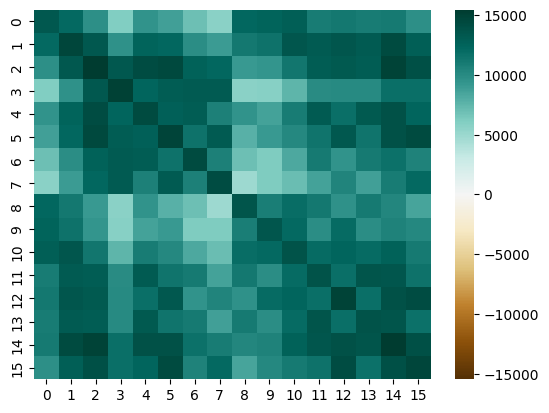

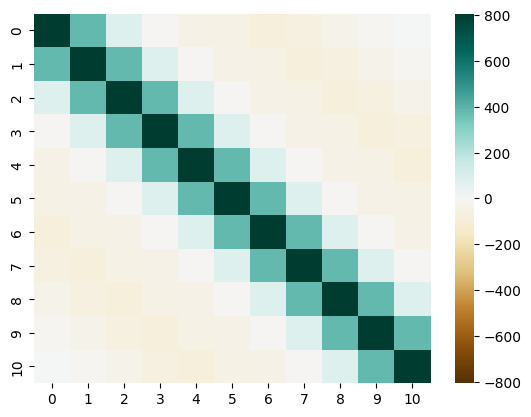

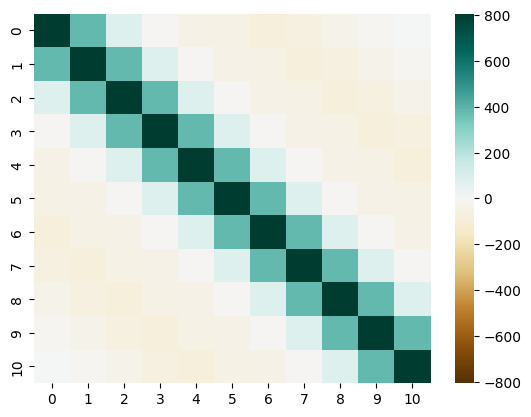

In [12]:
for k in range(3):
    cov = cupy.asnumpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(cov))
    _ = sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    _ = plt.show()

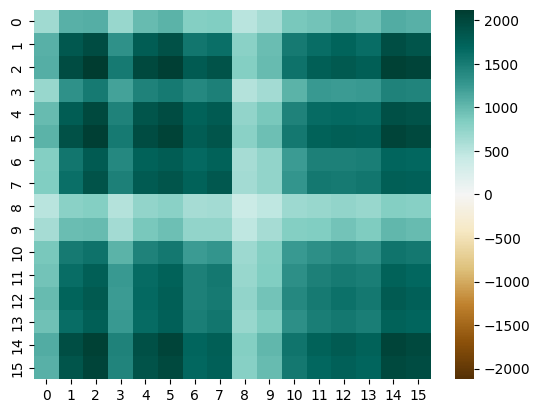

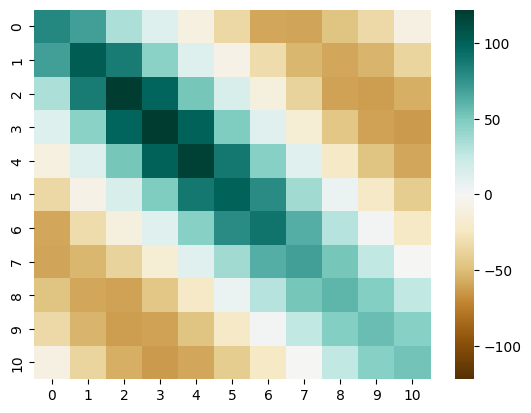

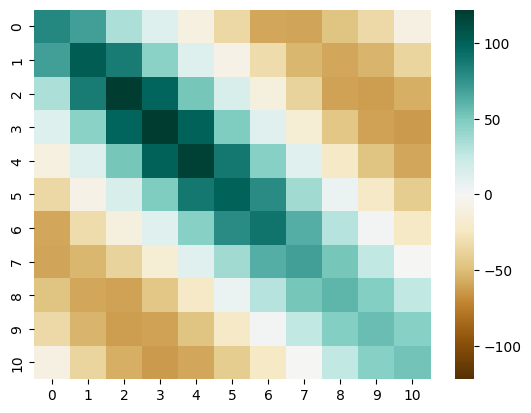

In [13]:
for k in range(3):
    cov = cupy.asnumpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

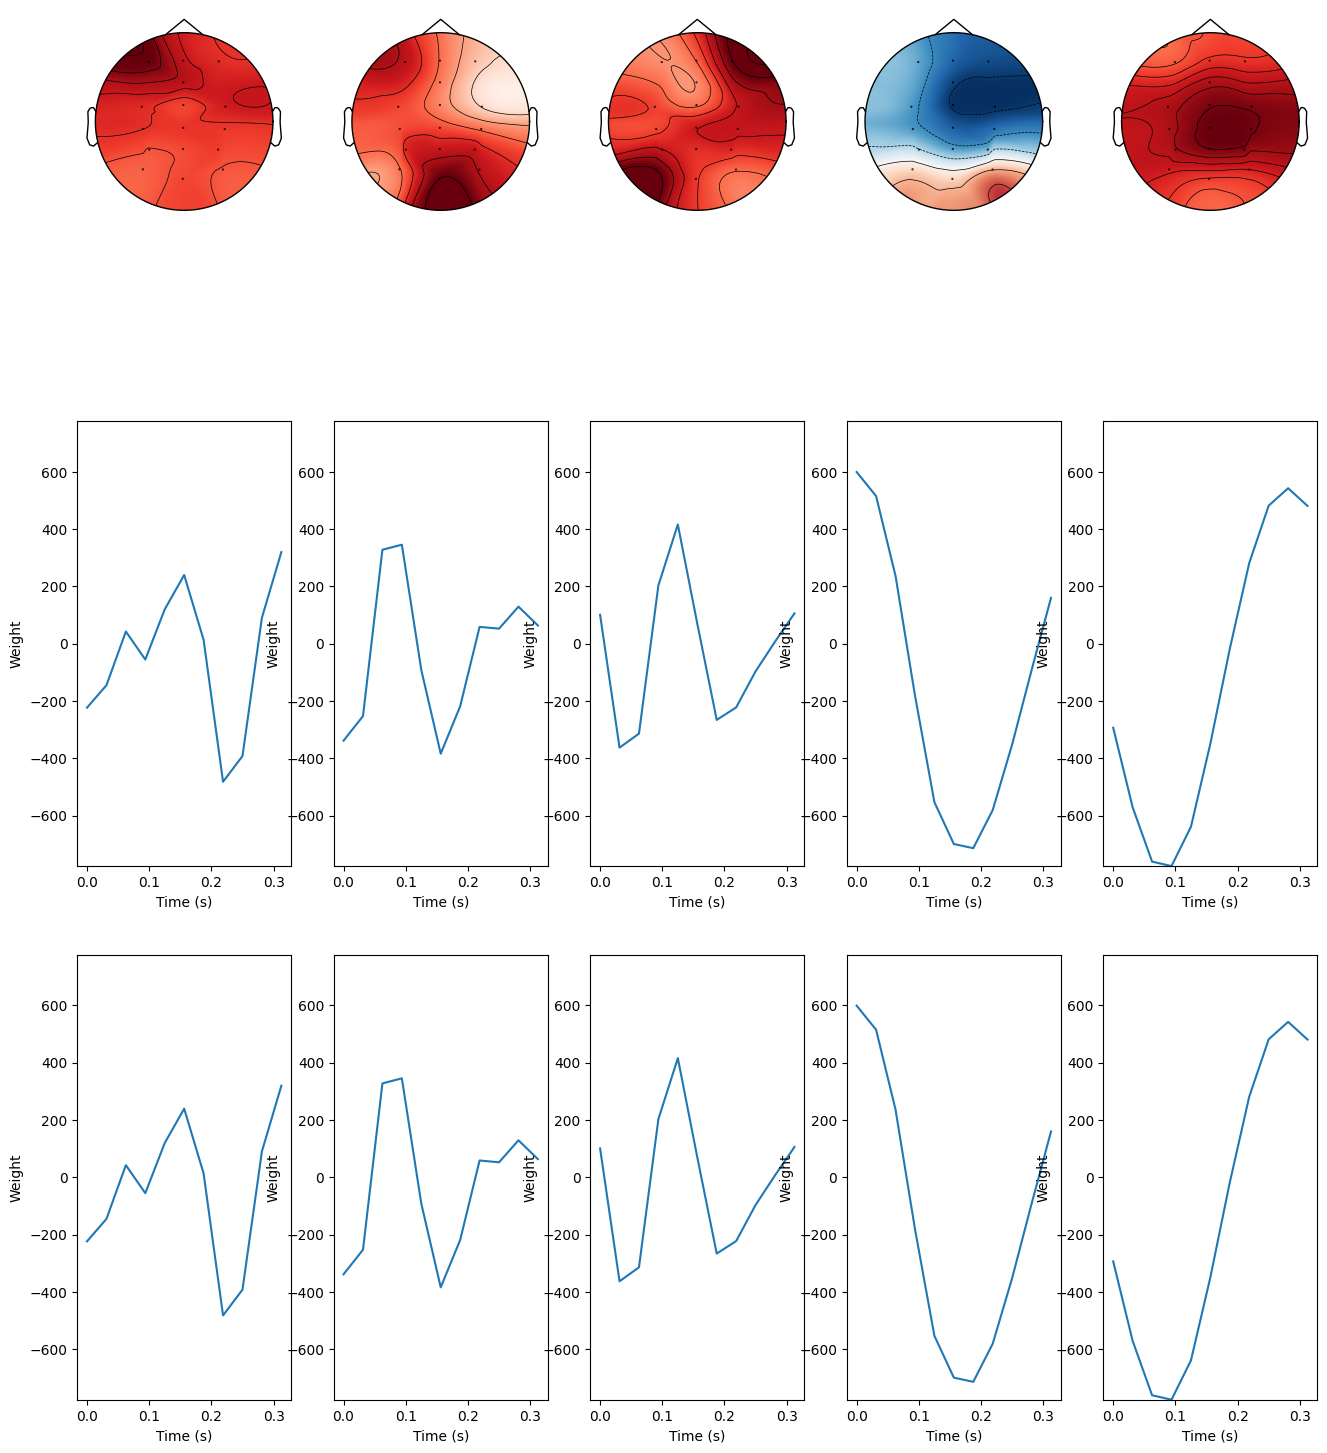

In [14]:
fig, axs = plt.subplots(3,hoda.rank, figsize=(16,6*3))
aps = [cupy.asnumpy(factors[k] @ hoda.scatter_w_[k] @ p) for k,p in enumerate(hoda.projs_)]
for i in range(hoda.rank):
    w = aps[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(aps[1]))
for i in range(hoda.rank):
    w = aps[1][:,i]
    axs[1,i].plot(epochs.times[:len(w)], w)
    axs[1,i].set_xlabel('Time (s)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])
    axs[1,i].sharex(axs[2,0])
    axs[1,i].sharey(axs[2,0])

for i in range(hoda.rank):
    w = aps[2][:,i]
    axs[2,i].plot(epochs.times[:len(w)], w)
    axs[2,i].set_xlabel('Time (s)')
    axs[2,i].set_ylabel('Weight')
    axs[2,i].set_ylim([-vmax, vmax])
    axs[2,i].sharex(axs[2,0])
    axs[2,i].sharey(axs[2,0])

In [15]:
Xt_train = cupy.asnumpy(hoda.transform(X_train))
Xt_test = cupy.asnumpy(hoda.transform(X_test))
tril_idc = np.tril_indices(5)

Xt_train_tri = np.zeros((*Xt_train.shape[:2], len(tril_idc[0])))
for i in range(Xt_train_tri.shape[0]):
    for c in range(Xt_train_tri.shape[1]):
        Xt_train_tri[i,c] = Xt_train[i,c][tril_idc]
Xt_train = Xt_train_tri.reshape((Xt_train_tri.shape[0],-1))
        
Xt_test_tri = np.zeros((*Xt_test.shape[:2], len(tril_idc[0])))
for i in range(Xt_test_tri.shape[0]):
    for c in range(Xt_test_tri.shape[1]):
        Xt_test_tri[i,c] = Xt_test[i,c][tril_idc]
Xt_test = Xt_test_tri.reshape((Xt_test_tri.shape[0],-1))


#Xt_train = Xt_train.reshape((Xt_train.shape[0],-1))
#Xt_test = Xt_test.reshape((Xt_test.shape[0],-1))

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

#classifier = LogisticRegression(penalty='l1', solver='liblinear')
classifier = LDA(solver='lsqr', shrinkage='auto')

classifier.fit(Xt_train,y_train)
classifier.fit(Xt_train,y_train)
feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()

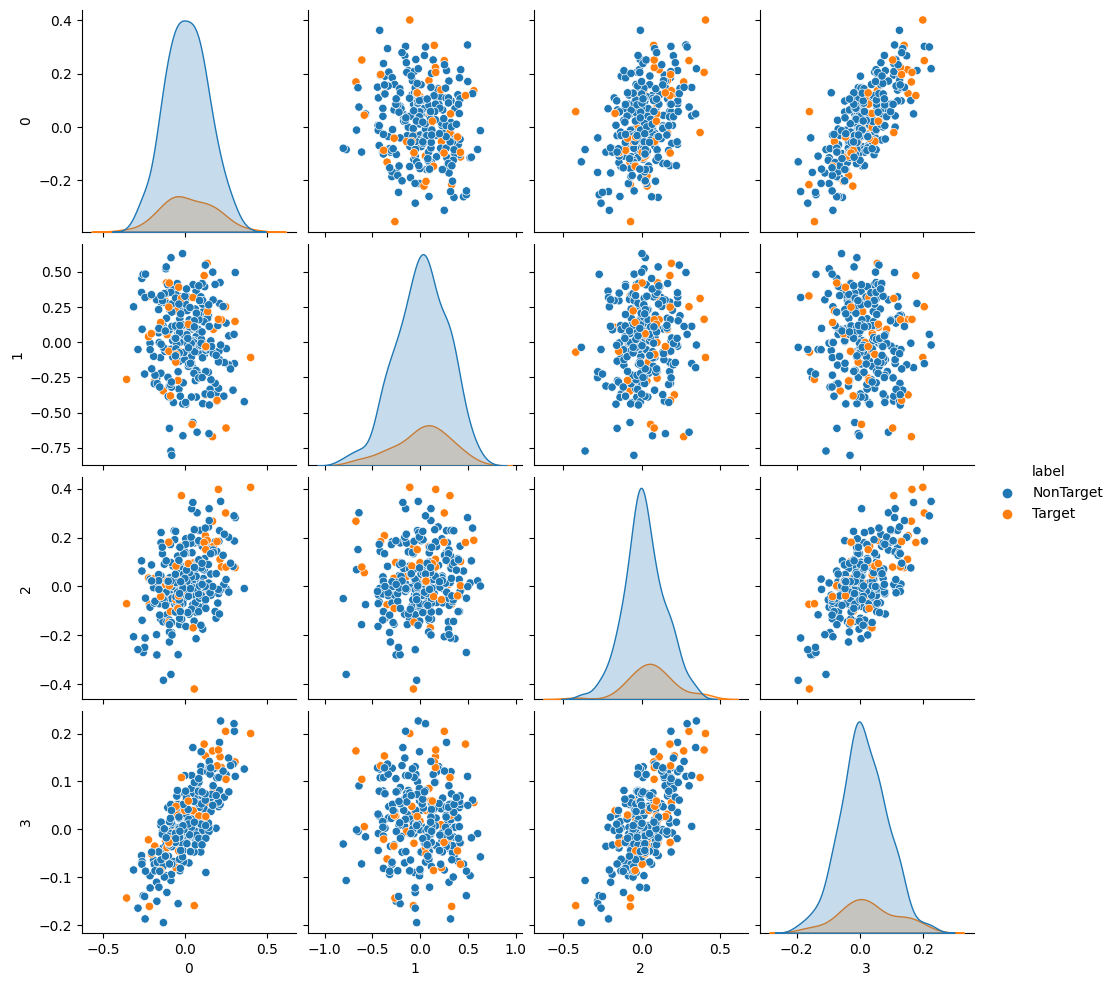

In [22]:
import seaborn as sns
import pandas as pd

n_features = Xt_train.shape[-1]
df_train = pd.DataFrame(Xt_train[:,feature_order[:4]])
df_train['label'] = y_train
g = sns.pairplot(df_train, hue='label')

In [23]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

0.9907986111111111

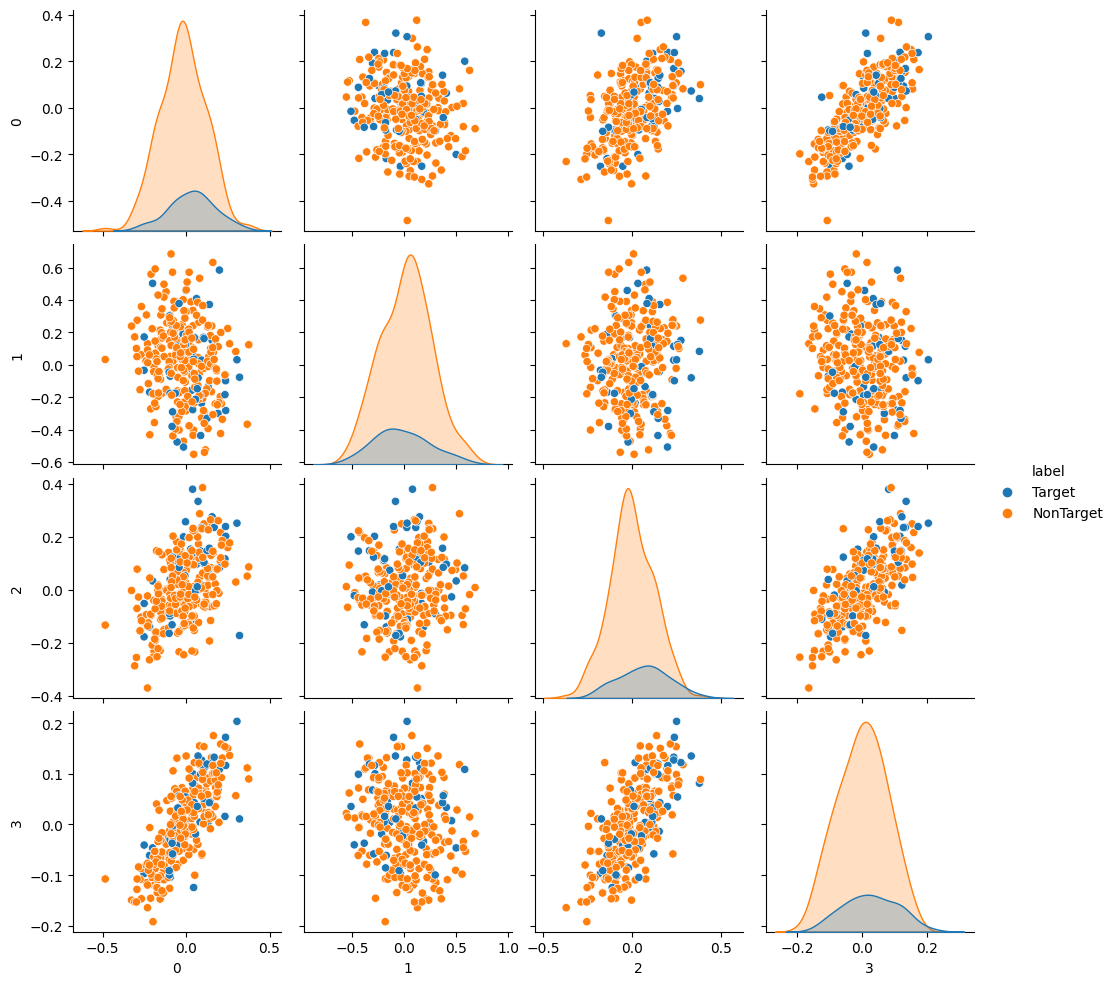

In [24]:
df_test = pd.DataFrame(Xt_test[:,feature_order[:4]])
df_test['label'] = y_test
g = sns.pairplot(df_test, hue='label')

In [25]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.9277777777777778